# Reward-proximity: do place-field peaks cluster near reward?

For each single-field and complex cell, this finds the (x, y) location of its
place-field peak (complex cells can have multiple peaks — detected via local-
maxima peak-finding on the smoothed tuning curve), then asks what fraction of
those peaks land within a given radius of a reward location, across several
radii (0.05-0.30 in the environment's normalized coordinates).

Demo networks: a no-reward baseline and a reward condition (magnitude x5),
same seed.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from prnn.utils.predictiveNet import PredictiveNet
import spatial_analysis as sa

DATA_DIR = REPO_ROOT / "data" / "trajectory"

OBS = [torch.tensor(np.load(DATA_DIR / f"obs{i}.npy")) for i in range(4)]
ACT = torch.tensor(np.load(DATA_DIR / "act.npy"))
STATE = {
    "agent_pos": torch.tensor(np.load(DATA_DIR / "pos.npy")),
    "agent_dir": torch.tensor(np.load(DATA_DIR / "dir.npy")),
    "mean_vel": 0.2,
}

wandb not installed, will not log to wandb


## 1. Classify cells, find place-field peaks (single + multi-peak complex), locate reward wells

In [2]:
RADII = [0.05, 0.10, 0.15, 0.20, 0.30]

def analyze(savename):
    net = PredictiveNet.loadNet(savename, savefolder=str(REPO_ROOT) + "/", dil=False)
    env = net.EnvLibrary[0]

    place_fields, SI, WAKE = sa.calculateSpatialRepresentation(net, env, OBS, ACT, STATE, saveTrainingData=False)
    metrics = sa.calculate_metrics(env, place_fields, SI, WAKE)
    groups, groupID = sa.groupCells(metrics)

    idx_single = np.flatnonzero(groups["single_field"])
    idx_complex = np.flatnonzero(groups["complex_cells"])
    start_pos = getattr(env, "start_pos", 0)

    XY_single = sa.centers_xy_from_rc(place_fields, idx_single, env, start_pos=start_pos)

    pf_complex_list = [place_fields[int(i)] for i in idx_complex]
    peaks_rc = sa.identify_peaks(pf_complex_list, cell_ids=idx_complex, threshold=0.6, neighborhood=1, sigma=0.8, min_distance=3)
    pf_complex_dict = {int(i): place_fields[int(i)] for i in idx_complex}
    peaks_xy = sa.peaks_to_xy_centers(peaks_rc, pf_complex_dict, env)
    XY_complex_all_peaks = np.array([xy for lst in peaks_xy.values() for xy in lst], dtype=float).reshape(-1, 2)
    multi_peak_ids = [cid for cid, pk in peaks_rc.items() if len(pk) > 1]

    rewards_xy = getattr(env.Reward, "place_cell_centres", None)

    circles_by_radius = {
        r: dict(
            single=sa.build_circles(XY_single, rewards_xy, radius=r),
            single_plus_complex_multipeak=sa.build_circles(
                np.vstack([XY_single, XY_complex_all_peaks]) if len(XY_complex_all_peaks) else XY_single,
                rewards_xy, radius=r,
            ),
        )
        for r in RADII
    }
    return dict(
        env=env, rewards_xy=rewards_xy, XY_single=XY_single, XY_complex_all_peaks=XY_complex_all_peaks,
        n_single=len(idx_single), n_complex=len(idx_complex), n_multi_peak=len(multi_peak_ids),
        circles_by_radius=circles_by_radius,
    )


demo = {
    "base_no_reward": analyze("base_no_reward_s1001_ep5"),
    "random_rew_mult5": analyze("random_rew_mult5_s1001_ep5"),
}
for name, res in demo.items():
    print(f"{name}: {res['n_single']} single-field, {res['n_complex']} complex "
          f"({res['n_multi_peak']} multi-peak), reward locations: {res['rewards_xy']}")

Net Loaded from pathname


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/prnn/analysis/TuningCurveAnalysis.py:448: RuntimeWarning: invalid value encountered in double_scalars
  border_score = (mean_border_rate - mean_nonborder_rate) / (mean_border_rate + mean_nonborder_rate)


Net Loaded from pathname


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/process/tuning_curves.py:378: RuntimeWarning: invalid value encountered in true_divide
  fxfr = fx / fr
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/process/tuning_curves.py:389: RuntimeWarning: invalid value encountered in true_divide
  SI = SI / fr[:, 0, 0]
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/process/tuning_curves.py:290: Run

/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/prnn/analysis/TuningCurveAnalysis.py:448: RuntimeWarning: invalid value encountered in double_scalars
  border_score = (mean_border_rate - mean_nonborder_rate) / (mean_border_rate + mean_nonborder_rate)


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/prnn/analysis/TuningCurveAnalysis.py:501: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  centerlabeled = labeled == whicharea
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/prnn/analysis/TuningCurveAnalysis.py:501: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  centerlabeled = labeled == whicharea
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/prnn/analysis/TuningCurveAnalysis.py:510: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  centerlabeled = labeled == whicharea
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/prnn/analysis/TuningCurveAnalysis.py:510: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  centerlabeled = labeled == whicharea
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-

base_no_reward: 120 single-field, 549 complex (458 multi-peak), reward locations: [[0.95       0.87692308]
 [0.55       0.78461538]
 [0.35       0.32307692]]
random_rew_mult5: 103 single-field, 530 complex (452 multi-peak), reward locations: [[0.95       0.87692308]
 [0.55       0.78461538]
 [0.35       0.32307692]]


## 2. Fraction of place-field peaks near reward, by radius

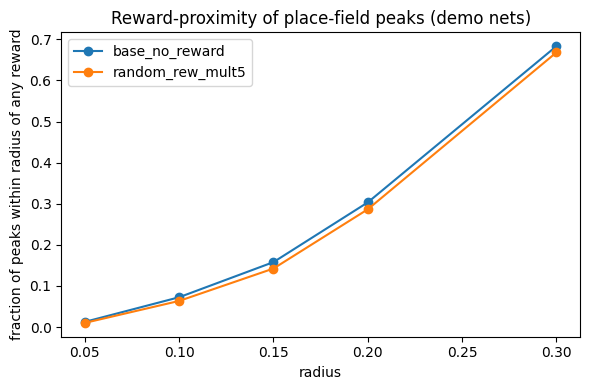

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, res in demo.items():
    fracs = [sum(res["circles_by_radius"][r]["single_plus_complex_multipeak"]["fractions"]) for r in RADII]
    ax.plot(RADII, fracs, marker="o", label=name)
ax.set_xlabel("radius")
ax.set_ylabel("fraction of peaks within radius of any reward")
ax.set_title("Reward-proximity of place-field peaks (demo nets)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Spatial layout: single-field cell peaks vs. reward locations

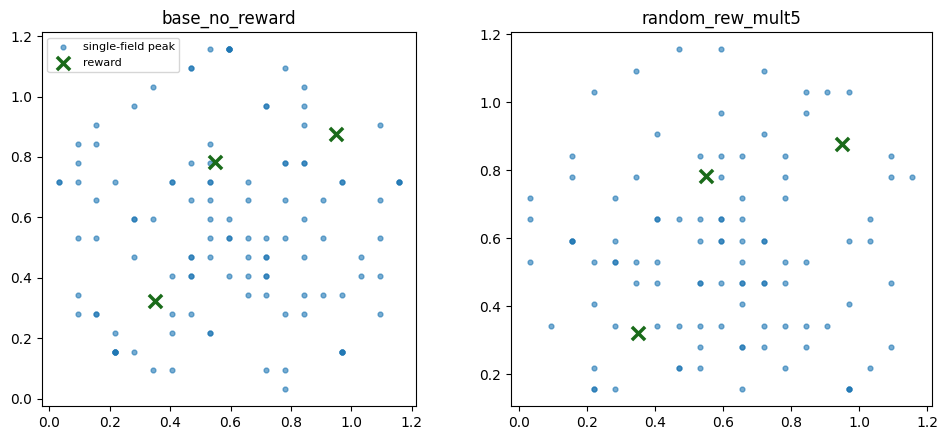

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (name, res) in zip(axes, demo.items()):
    ax.scatter(res["XY_single"][:, 0], res["XY_single"][:, 1], s=12, alpha=0.6, label="single-field peak")
    rxy = np.asarray(res["rewards_xy"])
    ax.scatter(rxy[:, 0], rxy[:, 1], s=90, marker="x", linewidths=2.5, color="#1a6b1a", label="reward")
    ax.set_title(name)
    ax.set_aspect("equal")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()